# packs

In [1]:
import transformers
from transformers import AutoModel, AutoTokenizer
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import numpy as np

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
!pip install datasets

In [5]:
from datasets import Dataset

In [6]:
from datasets import load_metric

# functions

## read data functions

In [7]:
def read_json(json_path):
  with open(json_path, 'r') as f:
    data = json.load(f)
    return data

In [8]:
def read_jsonl_file(nl_file_path, return_df=True):
    """
    :param return_df: return df with 'text', 'key', 'text_translated' columns
    :param nl_file_path:
    :return: list of dicts(keys: 'text', 'key', 'text_translated') per translation
    """
    with open(nl_file_path, 'r') as f:
        jsonl_content = f.read()
        result = [json.loads(jline) for jline in jsonl_content.splitlines()]
    if return_df:
        return pd.DataFrame(result)
    return result

In [9]:
def get_labels_tensor_from_data(data, label_key_name='label', labels_mapping = {'c': 0, 'e': 1, 'n': 2}, data_is_df=False):
  if data_is_df:
    str_labels = data[label_key_name].tolist()
  else:
    str_labels = [sample_[label_key_name] for sample_ in data]
  y = torch.tensor([labels_mapping[str_label.lower()] for str_label in str_labels], dtype=torch.int64)
  return y

In [10]:
def set_seed(seed):
    """
    Set the seed for reproducibility.

    Args:
        seed (int): The seed value to set.
    """
    # Set seed for Python's random module
    random.seed(seed)

    # Set seed for NumPy
    np.random.seed(seed)

    # Set seed for PyTorch CPU
    torch.manual_seed(seed)

    # Set seed for PyTorch CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # If you are using multiple GPUs

    # Ensure that CUDA operations are deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## eval model

In [11]:
def evaluate_model(model, test_x, y_test, labels_mapping, batch_size=32, device='cuda'):
    """
    Evaluates the given model on the test data and visualizes the results.

    Args:
        model (torch.nn.Module): The PyTorch model to evaluate.
        test_x (torch.Tensor): The input features for testing.
        y_test (torch.Tensor): The ground truth labels for testing.
        labels_mapping (dict): Dictionary mapping labels to indices.
        batch_size (int): The batch size for evaluation. Default is 32.
        device (str): The device to run the model on ('cuda' or 'cpu'). Default is 'cuda'.

    Returns:
        tuple: (predictions, accuracy, report) where:
            - predictions (torch.Tensor): The model's predictions on the test data.
            - accuracy (float): The accuracy of the model on the test data.
            - report (str): The classification report as a string.
    """
    model.eval()  # Set the model to evaluation mode

    # Move model and data to the specified device
    model.to(device)
    test_x = test_x.to(device)
    y_test = y_test.to(device)

    # Create a DataLoader for test data
    test_dataset = TensorDataset(test_x, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():  # No need to track gradients during evaluation
        for inputs, labels in test_loader:
            outputs = model(inputs)  # Forward pass
            _, preds = torch.max(outputs, 1)  # Get predictions
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    # Concatenate all predictions and labels
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Calculate accuracy
    correct = (all_preds == all_labels).sum().item()
    accuracy = correct / len(all_labels)

    # Mapping labels
    labels = [label for label, _ in sorted(labels_mapping.items(), key=lambda item: item[1])]

    # Compute and display confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=list(labels_mapping.values()))
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # Compute and display classification report
    report = classification_report(all_labels, all_preds, target_names=labels, digits=5)
    print("Classification Report:")
    print(report)

    return all_preds, accuracy, report

In [12]:
def evaluate_model_base_on_preds_and_res(y_preds, y_test, labels_mapping):
    # Calculate accuracy
    correct = (y_preds == y_test).sum().item()
    accuracy = correct / len(y_test)

    # Mapping labels
    labels = [label for label, _ in sorted(labels_mapping.items(), key=lambda item: item[1])]

    # Compute and display confusion matrix
    cm = confusion_matrix(y_test, y_preds, labels=list(labels_mapping.values()))
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # Compute and display classification report
    report = classification_report(y_test, y_preds, target_names=labels, digits=5)
    print("Classification Report:")
    print(report)

    return y_preds, accuracy, report

## inference functions

In [13]:
def extract_classifications_from_sample(model, tokenizer, sample, device, max_length=4096):

  inputs = tokenizer(sample, return_tensors="pt", truncation=True, padding="max_length", max_length=max_length).to(device)

  with torch.no_grad():
    outputs = model(**inputs)

  model_calssifications = outputs.logits.argmax(axis=1).cpu()
  return model_calssifications


def extract_embeddings_from_sample(model, tokenizer, sample, device, max_length=4096):

  inputs = tokenizer(sample, return_tensors="pt", truncation=True, padding="max_length", max_length=max_length).to(device)

  with torch.no_grad():
    outputs = model(**inputs)

  cls_embedding = outputs.last_hidden_state[:, 0, :].cpu()
  return cls_embedding


def extract_classifications_per_premise_hypothesis(model, tokenizer, device, data,
                                                   data_is_df=False,
                                                   premise_col_name='premise',
                                                   hypothesis_col_name='hypothesis',
                                                   inference_batch_size=10, max_length=4096,
                                                   ):
  model.to(device)

  model_classifications = []

  for i in tqdm(range(0, len(data), inference_batch_size)):
    if not data_is_df:
      batched_data = data[i:i+inference_batch_size]
      batch_df = pd.DataFrame(batched_data)
    else:
      batch_df = data.iloc[i:i+inference_batch_size]


    batch_cat_x = batch_df[premise_col_name] + ' [SEP] ' + batch_df[hypothesis_col_name] + ' [SEP] '
    cls_classi = extract_classifications_from_sample(model=model, tokenizer=tokenizer,
                                             device=device, sample=batch_cat_x.tolist(),
                                             max_length=max_length)

    model_classifications.append(cls_classi)

    # clean cuda mem
    del batched_data, batch_df, batch_cat_x, cls_classi
    torch.cuda.empty_cache()

  return torch.cat(model_classifications, dim=0)



def extract_embeddings_per_premise_hypothesis(model, tokenizer, device, data,
                                              data_is_df=False,
                                              premise_col_name='premise',
                                              hypothesis_col_name='hypothesis',
                                              inference_batch_size=10, max_length=4096,
                                              ):
  model.to(device)

  embeddings_ = []

  for i in tqdm(range(0, len(data), inference_batch_size)):
    if not data_is_df:
      batched_data = data[i:i+inference_batch_size]
      batch_df = pd.DataFrame(batched_data)
    else:
      batch_df = data.iloc[i:i+inference_batch_size]


    batch_cat_x = batch_df[premise_col_name] + ' [SEP] ' + batch_df[hypothesis_col_name] + ' [SEP] '
    cls_emb = extract_embeddings_from_sample(model=model, tokenizer=tokenizer,
                                             device=device, sample=batch_cat_x.tolist(),
                                             max_length=max_length)

    embeddings_.append(cls_emb)

    # clean cuda mem
    del batched_data, batch_df, batch_cat_x, cls_emb
    torch.cuda.empty_cache()

  return torch.cat(embeddings_, dim=0)

def run_and_save_embeddings_per_data_type(train_data, dev_data, test_data,
                                          model_name, model, tokenizer, device, destination_folder_path,
                                          max_length=4096, inference_batch_size=10, data_is_df=False,
                                          premise_col_name='premise', hypothesis_col_name='hypothesis',
                                          datasets_to_embbed=[1,1,1]):

  print(f'Extracting dataset embeddings by {model_name} model')

  if datasets_to_embbed[0] == 1:
    print(f'Extracting train...')
    train_embeddings = extract_embeddings_per_premise_hypothesis(model=model, tokenizer=tokenizer, device=device, data=train_data, max_length=max_length,
                                                                inference_batch_size=inference_batch_size, data_is_df=data_is_df,
                                                                premise_col_name=premise_col_name, hypothesis_col_name=hypothesis_col_name)
    path_train = f'{destination_folder_path}/{model_name}_x_train.pt'
    torch.save(train_embeddings, path_train)
    print(f'Saved train x ({path_train})')

  if datasets_to_embbed[1] == 1:
    print(f'Extracting dev...')
    dev_embeddings = extract_embeddings_per_premise_hypothesis(model=model, tokenizer=tokenizer, device=device, data=dev_data, max_length=max_length,
                                                              inference_batch_size=inference_batch_size, data_is_df=data_is_df,
                                                              premise_col_name=premise_col_name, hypothesis_col_name=hypothesis_col_name)
    path_dev = f'{destination_folder_path}/{model_name}_x_dev.pt'
    torch.save(dev_embeddings, path_dev)
    print(f'Saved dev x ({path_dev})')

  if datasets_to_embbed[2] == 1:
    print(f'Extracting test...')
    test_embeddings = extract_embeddings_per_premise_hypothesis(model=model, tokenizer=tokenizer, device=device, data=test_data, max_length=max_length,
                                                                inference_batch_size=inference_batch_size, data_is_df=data_is_df,
                                                                premise_col_name=premise_col_name, hypothesis_col_name=hypothesis_col_name)
    path_test = f'{destination_folder_path}/{model_name}_x_test.pt'
    torch.save(test_embeddings, path_test)
    print(f'Saved test x ({path_test})')

def tokenize_one_sample(tokenizer, sample, max_length):
  return tokenizer(sample, return_tensors="pt", truncation=True, padding="max_length", max_length=max_length)

def tokenize_in_batches(tokenizer, data_pairs, max_length=512, tokenizer_batch_size=128):
  n_samples = len(data_pairs)
  tokenized_data = []
  for i in tqdm(range(0, n_samples, tokenizer_batch_size)):
    sample = data_pairs[i:i+tokenizer_batch_size]
    tokenized_batch = tokenize_one_sample(tokenizer=tokenizer, sample=sample,
                                          max_length=max_length)
    tokenized_data.append(tokenized_batch)
  return tokenized_data

## train functions

In [14]:
def create_dataloader(x, y, batch_size=32, shuffle=True):
  dataset = TensorDataset(x, y)
  loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
  return loader

def train_step(model, data_loader, loss_fn, optimizer, device):
  model.train()  # Set the model to training mode
  for inputs, targets in tqdm(data_loader):
    inputs, targets = inputs.to(device), targets.to(device)

    # Zero the gradients
    optimizer.zero_grad()
    # Forward pass
    outputs = model(inputs)
    loss = loss_fn(outputs, targets)

    # Backward pass and optimize
    loss.backward()
    optimizer.step()

def validate_model(model, data_loader, loss_fn, device):
  model.eval()  # Set the model to evaluation mode
  total_loss = 0
  correct_predictions = 0

  with torch.no_grad():
      for inputs, targets in tqdm(data_loader):
          inputs, targets = inputs.to(device), targets.to(device)
          outputs = model(inputs)
          loss = loss_fn(outputs, targets)
          total_loss += loss.item()

          # For multi-class classification, use argmax to get the predicted class
          predicted_classes = outputs.argmax(dim=1)
          correct_predictions += (predicted_classes == targets).sum().item()

  average_loss = total_loss / len(data_loader)
  accuracy = correct_predictions / len(data_loader.dataset)
  return average_loss, accuracy


def train_model(x_train, y_train, x_val, y_val, model, epochs, checkpoints_dir_path, batch_size=32, learning_rate=1e-4, weight_decay=1e-2, save_checkpoints=True):
  # Move model to the appropriate compute device
  device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
  model.to(device)

  # Create training and validation data loaders
  train_loader = create_dataloader(x_train, y_train, batch_size, shuffle=True)
  val_loader = create_dataloader(x_val, y_val, batch_size, shuffle=False)

  # Define loss function and optimizer
  loss_fn = nn.CrossEntropyLoss()
  # optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

  train_losses, val_losses = [],[]

  # Training loop
  for epoch in range(epochs):
    print(f'\n\n**Epoch #{epoch+1}')
    train_step(model, train_loader, loss_fn, optimizer, device)

    print('Finished training step, checking loss on train')
    train_loss, train_accuracy = validate_model(model, train_loader, loss_fn, device)
    train_losses.append(train_loss)

    print('Checking loss on validation')
    val_loss, val_accuracy = validate_model(model, val_loader, loss_fn, device)
    val_losses.append(val_loss)

    print(f'Train Epoch {epoch+1}/{epochs} Stats- Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}; Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

    # Save checkpoints
    if save_checkpoints:
      torch.save(model.state_dict(), f'{checkpoints_dir_path}/epoch_{epoch+1}_{round(val_loss,2)}_val_loss.pth')
      np.save(f'{checkpoints_dir_path}/train_losses.npy', np.array(train_losses))
      np.save(f'{checkpoints_dir_path}/val_losses.npy', np.array(val_losses))

  print("Training complete!")


In [15]:
def compute_accuracy(labels, preds):
    # Convert logits to predicted class (0 or 1)
    pred_labels = np.argmax(preds, axis=1)
    # Calculate accuracy
    accuracy = (labels == pred_labels).mean()
    return {"accuracy": accuracy}

# Function to compute metrics for Hugging Face Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return compute_accuracy(labels, logits)

# read data

## HEB SNLI

In [16]:
snli_train_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/SNLI/HebNLI_train.jsonl'
snli_dev_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/SNLI/HebNLI_val.jsonl'
snli_test_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/SNLI/HebNLI_test.jsonl'

In [17]:
snli_train_data = read_jsonl_file(snli_train_path_file)
snli_dev_data = read_jsonl_file(snli_dev_path_file)
snli_test_data = read_jsonl_file(snli_test_path_file)

In [18]:
snli_labels_mapping = {'contradiction': 0, 'entailment': 1, 'neutral': 2, '-':3}
snli_y_train = get_labels_tensor_from_data(snli_train_data, labels_mapping=snli_labels_mapping, label_key_name='original_label', data_is_df=True)
snli_y_dev = get_labels_tensor_from_data(snli_dev_data, labels_mapping=snli_labels_mapping, label_key_name='original_label', data_is_df=True)
snli_y_test = get_labels_tensor_from_data(snli_test_data, labels_mapping=snli_labels_mapping, label_key_name='original_label', data_is_df=True)

In [19]:
snli_y_train.shape, snli_y_dev.shape, snli_y_test.shape

(torch.Size([300150]), torch.Size([2000]), torch.Size([884]))

In [20]:
map_cleaned_train_samples = (snli_y_train != 3).numpy()
map_cleaned_dev_samples = (snli_y_dev != 3).numpy()
map_cleaned_test_samples = (snli_y_test != 3).numpy()

In [21]:
snli_train_data = snli_train_data[map_cleaned_train_samples].reset_index(drop=True)
snli_dev_data = snli_dev_data[map_cleaned_dev_samples].reset_index(drop=True)
snli_test_data = snli_test_data[map_cleaned_test_samples].reset_index(drop=True)

In [22]:
snli_y_train = snli_y_train[map_cleaned_train_samples]
snli_y_dev = snli_y_dev[map_cleaned_dev_samples]
snli_y_test = snli_y_test[map_cleaned_test_samples]

## HEB Control

### DIKTA

In [ ]:
# train_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/translations/dikta_train_data.parquet'
# dev_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/translations/dikta_heb_dev.json'
# test_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/translations/dikta_heb_test.json'

In [ ]:
# train_data_parquet = pd.read_parquet(train_path_file)
# train_data = train_data_parquet.to_dict(orient='records')
# dev_data = read_json(dev_path_file)
# test_data = read_json(test_path_file)

In [ ]:
# y_train = get_labels_tensor_from_data(train_data)
# y_dev = get_labels_tensor_from_data(dev_data)
# y_test = get_labels_tensor_from_data(test_data)

In [ ]:
# y_train.shape, y_dev.shape, y_test.shape

(torch.Size([6719]), torch.Size([799]), torch.Size([805]))

### AWS

In [23]:
train_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/translations/aws_heb_train.json'
dev_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/translations/aws_heb_dev.json'
test_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/translations/aws_heb_test.json'

In [24]:
train_data = read_json(train_path_file)
dev_data = read_json(dev_path_file)
test_data = read_json(test_path_file)

In [25]:
uids_to_remove_from_aws_data = ['id_2456','id_2457','id_2458','id_2459'] #text_2851 wasn't translated
def filter_dicts(list_of_dicts, values_to_exclude, key_name):
    return [d for d in list_of_dicts if d.get(key_name) not in values_to_exclude]

train_data = filter_dicts(list_of_dicts=train_data, values_to_exclude=uids_to_remove_from_aws_data, key_name='uid')

In [26]:
y_train = get_labels_tensor_from_data(train_data)
y_dev = get_labels_tensor_from_data(dev_data)
y_test = get_labels_tensor_from_data(test_data)

In [27]:
y_train.shape, y_dev.shape, y_test.shape

(torch.Size([6715]), torch.Size([799]), torch.Size([805]))

## Control origin CONTROL

In [ ]:
train_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/control_eng/train.jsonl'
dev_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/control_eng/dev.jsonl'
test_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/data/control_eng/test.jsonl'

In [ ]:
train_data = read_jsonl_file(train_path_file, return_df=False)
dev_data = read_jsonl_file(dev_path_file, return_df=False)
test_data = read_jsonl_file(test_path_file, return_df=False)

In [ ]:
y_train = get_labels_tensor_from_data(train_data)
y_dev = get_labels_tensor_from_data(dev_data)
y_test = get_labels_tensor_from_data(test_data)

In [ ]:
y_train.shape, y_dev.shape, y_test.shape

# FineTuning

In [28]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

## relvant model loading

In [29]:
tokenizer = AutoTokenizer.from_pretrained('onlplab/alephbert-base')
model = AutoModelForSequenceClassification.from_pretrained('onlplab/alephbert-base', num_labels=3)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/545k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at onlplab/alephbert-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## preprocess data

### HEB SNLI

In [30]:
snli_train_df = pd.DataFrame(snli_train_data)
snli_dev_df = pd.DataFrame(snli_dev_data)
snli_test_df = pd.DataFrame(snli_test_data)

In [31]:
snli_train_df['paires'] = snli_train_df['translation1'] + ' [SEP] ' + snli_train_df['translation2'] + ' [SEP] '
snli_dev_df['paires'] = snli_dev_df['translation1'] + ' [SEP] ' + snli_dev_df['translation2'] + ' [SEP] '
snli_test_df['paires'] = snli_test_df['translation1'] + ' [SEP] ' + snli_test_df['translation2'] + ' [SEP] '

In [32]:
snli_train_pairs = snli_train_df['paires'].tolist()
snli_dev_pairs = snli_dev_df['paires'].tolist()
snli_test_pairs = snli_test_df['paires'].tolist()

In [33]:
snli_tokenized_train = tokenize_one_sample(tokenizer=tokenizer, sample=snli_train_pairs, max_length=256)
snli_tokenized_dev = tokenize_one_sample(tokenizer=tokenizer, sample=snli_dev_pairs, max_length=256)
snli_tokenized_test = tokenize_one_sample(tokenizer=tokenizer, sample=snli_test_pairs, max_length=256)

In [34]:
snli_train_data = Dataset.from_dict({
    'input_ids': snli_tokenized_train['input_ids'],
    'attention_mask': snli_tokenized_train['attention_mask'],
    'labels': snli_y_train
})

snli_dev_data = Dataset.from_dict({
    'input_ids': snli_tokenized_dev['input_ids'],
    'attention_mask': snli_tokenized_dev['attention_mask'],
    'labels': snli_y_dev
})

snli_test_data = Dataset.from_dict({
    'input_ids': snli_tokenized_test['input_ids'],
    'attention_mask': snli_tokenized_test['attention_mask'],
    'labels': snli_y_test
})

### LCHAIM

In [35]:
train_df = pd.DataFrame(train_data)
dev_df = pd.DataFrame(dev_data)
test_df = pd.DataFrame(test_data)

In [36]:
train_df['paires'] = train_df['premise'] + ' [SEP] ' + train_df['hypothesis'] + ' [SEP] '
dev_df['paires'] = dev_df['premise'] + ' [SEP] ' + dev_df['hypothesis'] + ' [SEP] '
test_df['paires'] = test_df['premise'] + ' [SEP] ' + test_df['hypothesis'] + ' [SEP] '

In [37]:
train_pairs = train_df['paires'].tolist()
dev_pairs = dev_df['paires'].tolist()
test_pairs = test_df['paires'].tolist()

In [38]:
tokenized_train = tokenize_one_sample(tokenizer=tokenizer, sample=train_pairs, max_length=512)
tokenized_dev = tokenize_one_sample(tokenizer=tokenizer, sample=dev_pairs, max_length=512)
tokenized_test = tokenize_one_sample(tokenizer=tokenizer, sample=test_pairs, max_length=512)

In [39]:
lchaim_train_data = Dataset.from_dict({
    'input_ids': tokenized_train['input_ids'],
    'attention_mask': tokenized_train['attention_mask'],
    'labels': y_train
})

lchaim_dev_data = Dataset.from_dict({
    'input_ids': tokenized_dev['input_ids'],
    'attention_mask': tokenized_dev['attention_mask'],
    'labels': y_dev
})

lchaim_test_data = Dataset.from_dict({
    'input_ids': tokenized_test['input_ids'],
    'attention_mask': tokenized_test['attention_mask'],
    'labels': y_test
})


## Run training

In [40]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=1e-5,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1494: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


### HEB SNLI

In [42]:
snli_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=snli_train_data,
    eval_dataset=snli_dev_data,
    compute_metrics=compute_metrics,
)

In [ ]:
snli_trainer.train()

In [ ]:
model.save_pretrained('/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/snli')
tokenizer.save_pretrained('/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/snli')

('/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/snli/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/snli/special_tokens_map.json',
 '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/snli/vocab.txt',
 '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/snli/added_tokens.json',
 '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/snli/tokenizer.json')

In [51]:
results = snli_trainer.predict(test_dataset=snli_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics

SNLI test set after FT on SNLI


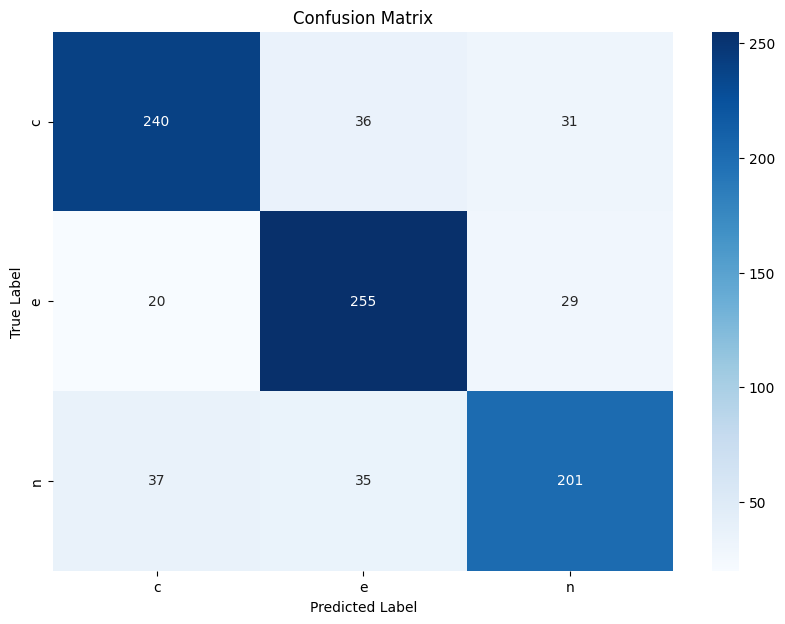

Classification Report:
              precision    recall  f1-score   support

           c    0.80808   0.78176   0.79470       307
           e    0.78221   0.83882   0.80952       304
           n    0.77011   0.73626   0.75281       273

    accuracy                        0.78733       884
   macro avg    0.78680   0.78561   0.78568       884
weighted avg    0.78746   0.78733   0.78686       884



In [52]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('SNLI test set after FT on SNLI')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=snli_y_test.numpy(), labels_mapping=labels_mapping)

In [53]:
results = snli_trainer.predict(test_dataset=lchaim_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics

AWS LCHAIM test set after FT on SNLI


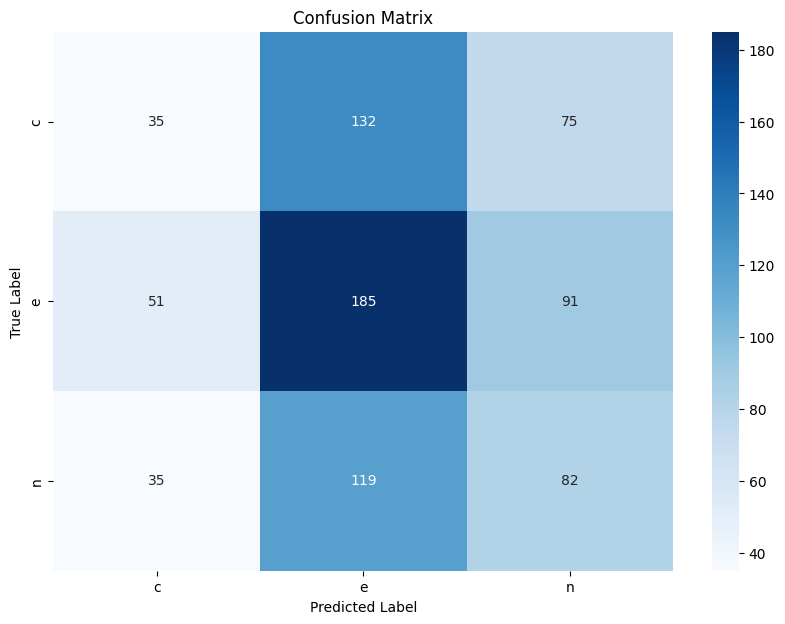

Classification Report:
              precision    recall  f1-score   support

           c    0.28926   0.14463   0.19284       242
           e    0.42431   0.56575   0.48493       327
           n    0.33065   0.34746   0.33884       236

    accuracy                        0.37516       805
   macro avg    0.34807   0.35261   0.33887       805
weighted avg    0.35625   0.37516   0.35429       805



In [54]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('AWS LCHAIM test set after FT on SNLI')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=y_test.numpy(), labels_mapping=labels_mapping)

###LCHAIM

In [50]:
tokenizer = AutoTokenizer.from_pretrained('/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/snli')
model = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/snli')

In [55]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=1e-5,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1494: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [56]:
lchaim_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lchaim_train_data,
    eval_dataset=lchaim_dev_data,
    compute_metrics=compute_metrics
)
lchaim_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.089800,1.091598,0.413016
2,1.037600,1.044225,0.463079


TrainOutput(global_step=420, training_loss=1.1099617186046782, metrics={'train_runtime': 552.2624, 'train_samples_per_second': 24.318, 'train_steps_per_second': 0.761, 'total_flos': 3533613200087040.0, 'train_loss': 1.1099617186046782, 'epoch': 2.0})

In [57]:
model.save_pretrained('/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/ft_aws_snli')
tokenizer.save_pretrained('/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/ft_aws_snli')

('/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/ft_aws_snli/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/ft_aws_snli/special_tokens_map.json',
 '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/ft_aws_snli/vocab.txt',
 '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/ft_aws_snli/added_tokens.json',
 '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/ft_aws_snli/tokenizer.json')

In [58]:
results = lchaim_trainer.predict(test_dataset=lchaim_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics

AWS LCHAIM test set after FT on SNLI+AWS-LCHAIM


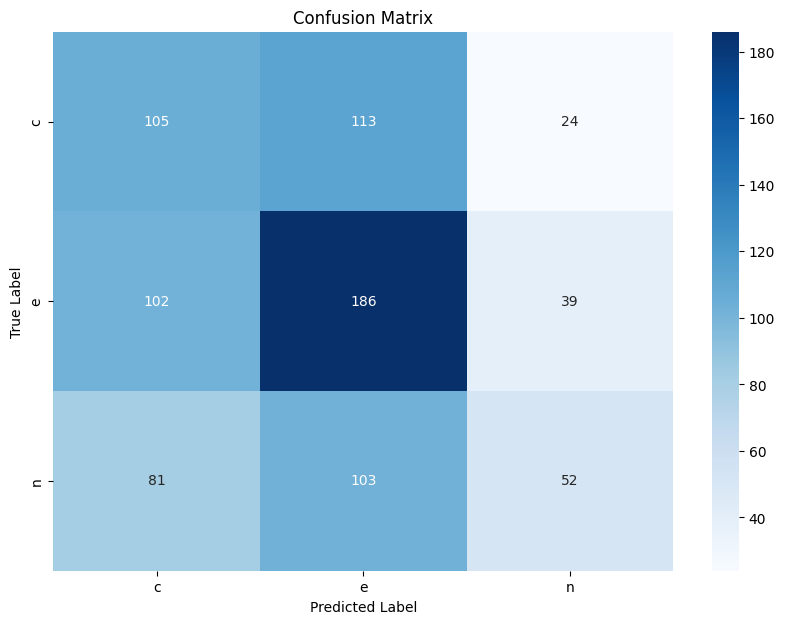

Classification Report:
              precision    recall  f1-score   support

           c    0.36458   0.43388   0.39623       242
           e    0.46269   0.56881   0.51029       327
           n    0.45217   0.22034   0.29630       236

    accuracy                        0.42609       805
   macro avg    0.42648   0.40768   0.40094       805
weighted avg    0.43011   0.42609   0.41326       805



In [59]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('AWS LCHAIM test set after FT on SNLI+AWS-LCHAIM')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=y_test.numpy(), labels_mapping=labels_mapping)

SNLI test set after FT on SNLI+AWS-LCHAIM


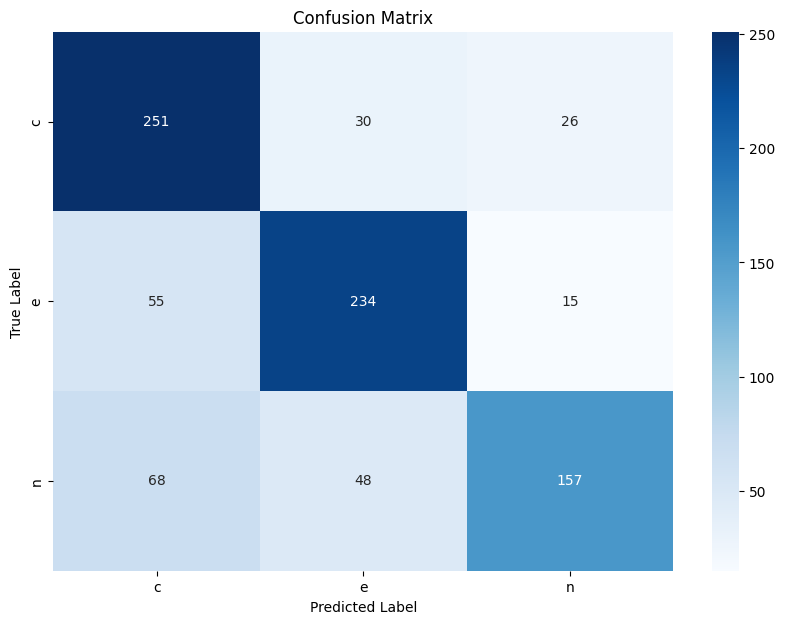

Classification Report:
              precision    recall  f1-score   support

           c    0.67112   0.81759   0.73715       307
           e    0.75000   0.76974   0.75974       304
           n    0.79293   0.57509   0.66667       273

    accuracy                        0.72624       884
   macro avg    0.73802   0.72081   0.72119       884
weighted avg    0.73586   0.72624   0.72315       884



In [62]:
results = lchaim_trainer.predict(test_dataset=snli_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('SNLI test set after FT on SNLI+AWS-LCHAIM')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=snli_y_test.numpy(), labels_mapping=labels_mapping)

# Output hidden states per sample

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

## Origin Control (ENG)

### Bert-Base

In [ ]:
model_name = 'bert_base'
folder_to_save_data = f'/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/control_eng/{model_name}'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
run_and_save_embeddings_per_data_type(train_data=train_data, dev_data=dev_data, test_data=test_data,
                                      model_name=model_name, model=model, tokenizer=tokenizer, device=device,
                                      max_length=512, inference_batch_size=512,
                                      destination_folder_path=folder_to_save_data,
                                      datasets_to_embbed=[1,0,0])

Extracting dataset embeddings by bert_base model
Extracting train...


100%|██████████| 14/14 [03:10<00:00, 13.61s/it]

Saved train x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/control_eng/bert_base/bert_base_x_train.pt)


### LongFormer

In [ ]:
model_name = 'longformer'
folder_to_save_data = f'/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/control_eng/{model_name}'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('allenai/longformer-base-4096')
model = AutoModel.from_pretrained('allenai/longformer-base-4096')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

In [ ]:
run_and_save_embeddings_per_data_type(train_data=train_data, dev_data=dev_data, test_data=test_data,
                                      model_name=model_name, model=model, tokenizer=tokenizer, device=device,
                                      max_length=4096, inference_batch_size=30,
                                      destination_folder_path=folder_to_save_data,
                                      datasets_to_embbed=[1,1,0])

Extracting dataset embeddings by longformer model
Extracting train...


100%|██████████| 224/224 [30:03<00:00,  8.05s/it]


Saved train x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/control_eng/longformer/longformer_x_train.pt)
Extracting dev...


100%|██████████| 27/27 [03:35<00:00,  7.96s/it]

Saved dev x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/control_eng/longformer/longformer_x_dev.pt)


## LCHAIM (HEB Control)

In [ ]:
translation_type = 'aws_translation'
dataset = 'lchaim'

In [ ]:
folder_to_save_data = f'/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/{dataset}/{translation_type}'
folder_to_save_data

'/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/control/aws_translation'

### LongHero

In [ ]:
model_name = 'longhero'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('HeNLP/LongHeRo')
model = AutoModel.from_pretrained('HeNLP/LongHeRo')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of LongformerModel were not initialized from the model checkpoint at HeNLP/LongHeRo and are newly initialized: ['longformer.pooler.dense.bias', 'longformer.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
run_and_save_embeddings_per_data_type(train_data, dev_data, test_data,
                                      model_name, model, tokenizer, device,
                                      max_length=3000, inference_batch_size=25,
                                      destination_folder_path=folder_to_save_data,
                                      datasets_to_embbed=[1,0,0])

Extracting dataset embeddings by longhero model
Extracting train...


100%|██████████| 269/269 [32:25<00:00,  7.23s/it]

Saved train x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/control/aws_translation/longhero_x_train.pt)


### AlephBert

In [ ]:
model_name = 'alephbert'

In [ ]:
folder_to_save_data = f'/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/{dataset}/{translation_type}/{model_name}'
folder_to_save_data

'/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/lchaim/aws_translation/alephbert'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('onlplab/alephbert-base')
model = AutoModel.from_pretrained('onlplab/alephbert-base')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/545k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at onlplab/alephbert-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
run_and_save_embeddings_per_data_type(train_data=train_data,
                                      dev_data=dev_data,
                                      test_data=test_data,
                                      model_name=model_name,
                                      model=model, tokenizer=tokenizer,
                                      device=device, max_length=512, inference_batch_size=512,
                                      destination_folder_path=folder_to_save_data)

Extracting dataset embeddings by alephbert model
Extracting train...


100%|██████████| 14/14 [01:37<00:00,  6.96s/it]


Saved train x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/lchaim/aws_translation/longhero/alephbert_x_train.pt)
Extracting dev...


100%|██████████| 2/2 [00:11<00:00,  5.79s/it]


Saved dev x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/lchaim/aws_translation/longhero/alephbert_x_dev.pt)
Extracting test...


100%|██████████| 2/2 [00:11<00:00,  5.91s/it]

Saved test x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/lchaim/aws_translation/longhero/alephbert_x_test.pt)


## SNLI

In [ ]:
run_and_save_embeddings_per_data_type(snli_train, snli_dev, snli_test,
                                      model_name, model, tokenizer, device,
                                      max_length=512, inference_batch_size=8,
                                      destination_folder_path=f'{folder_to_save_data}/snli',
                                      premise_col_name='translation1', hypothesis_col_name='translation2'
                                      )

### AlephBert

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('onlplab/alephbert-base')
model = AutoModel.from_pretrained('onlplab/alephbert-base')
run_and_save_embeddings_per_data_type(snli_train, snli_dev, snli_test,
                                      model_name, model, tokenizer, device,
                                      max_length=512, inference_batch_size=512,
                                      destination_folder_path=f'{folder_to_save_data}/snli',
                                      premise_col_name='translation1', hypothesis_col_name='translation2'
                                      )

Extracting dataset embeddings by alephbert model
Extracting train...


100%|██████████| 587/587 [1:11:06<00:00,  7.27s/it]


Saved train x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/alephbert_x_train.pt)
Extracting dev...


100%|██████████| 4/4 [00:28<00:00,  7.11s/it]


Saved dev x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/alephbert_x_dev.pt)
Extracting test...


100%|██████████| 2/2 [00:12<00:00,  6.27s/it]

Saved test x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/alephbert_x_test.pt)


# Train MLP

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, classifier_input_size=768):
        super(MLPClassifier, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(classifier_input_size, 300), # l1
            nn.ReLU(),
            nn.LayerNorm(300),
            nn.Dropout(0.3),
            nn.Linear(300, 100), # l2
            nn.ReLU(),
            nn.LayerNorm(100),
            nn.Dropout(0.3),
            nn.Linear(100, 50), # l3
            nn.ReLU(),
            nn.LayerNorm(50),
        )
        self.output_layer = nn.Linear(50, 3)  # 3 classes

    def forward(self, x):
        x = self.hidden_layers(x)
        x = self.output_layer(x)
        return x


class MLPClassifier(nn.Module):
    def __init__(self, classifier_input_size=768):
        super(MLPClassifier, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(classifier_input_size, 3), # l1
        )

    def forward(self, x):
        x = self.hidden_layers(x)
        return x

## MLP control

In [ ]:
model_name = 'longhero'
tranlation_type = 'aws_translation'
dataset_name = 'Test on LCHAIM AWS'
folder_to_save_data = f'/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/lchaim/{tranlation_type}/{model_name}'
folder_to_save_data

'/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/lchaim/aws_translation/longhero'

In [ ]:
train_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_train.pt')
dev_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_dev.pt')
test_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_test.pt')

In [ ]:
set_seed(42)
classifier_model = MLPClassifier()
train_model(x_train=train_embeddings, y_train=y_train.long(), x_val=dev_embeddings, y_val=y_dev,
            model=classifier_model, learning_rate=1e-4, batch_size=32,
            epochs=10, checkpoints_dir_path='/content')



**Epoch #1


100%|██████████| 210/210 [00:00<00:00, 727.08it/s]


Finished training step, checking loss on train


100%|██████████| 210/210 [00:00<00:00, 1498.02it/s]


Checking loss on validation


...

Finished training step, checking loss on train


100%|██████████| 210/210 [00:00<00:00, 1487.44it/s]


Checking loss on validation


100%|██████████| 25/25 [00:00<00:00, 1335.19it/s]

Train Epoch 10/10 Stats- Train Loss: 1.0742, Train Accuracy: 0.4018; Val Loss: 1.1002, Val Accuracy: 0.3605
Training complete!


In [ ]:
train_loss = np.load('/content/train_losses.npy')
val_loss = np.load('/content/val_losses.npy')

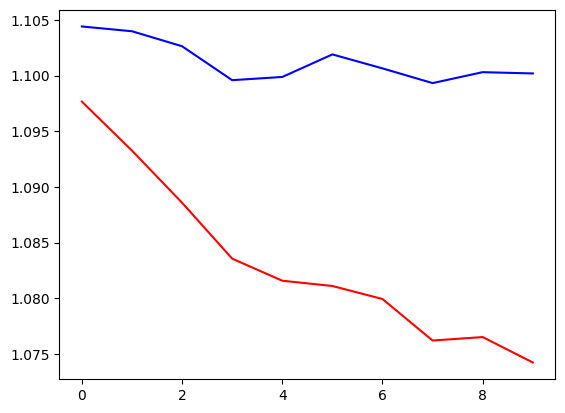

In [ ]:
plt.plot(train_loss, c='r')
plt.plot(val_loss, c='b')
plt.show()

MLP Model result for longhero, (data:Test on LCHAIM AWS)


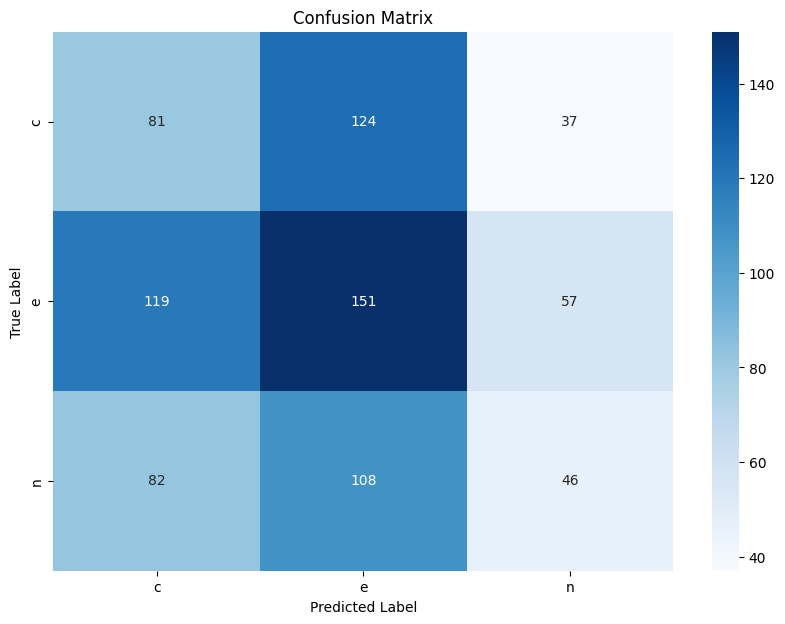

Classification Report:
              precision    recall  f1-score   support

           c    0.28723   0.33471   0.30916       242
           e    0.39426   0.46177   0.42535       327
           n    0.32857   0.19492   0.24468       236

    accuracy                        0.34534       805
   macro avg    0.33669   0.33047   0.32640       805
weighted avg    0.34283   0.34534   0.33746       805



In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'MLP Model result for {model_name}, (data:{dataset_name})')
res = evaluate_model(model=classifier_model, test_x=test_embeddings, y_test=y_test, labels_mapping=labels_mapping)

## MLP SNLI

In [ ]:
train_embeddings = torch.load(f'{folder_to_save_data}/snli/snli_{model_name}_x_train.pt')
dev_embeddings = torch.load(f'{folder_to_save_data}/snli/snli_{model_name}_x_dev.pt')
test_embeddings = torch.load(f'{folder_to_save_data}/snli/snli_{model_name}_x_test.pt')

In [ ]:
mappind_snli_train = snli_y_train != 3
mappind_snli_dev = snli_y_dev != 3
mappind_snli_test = snli_y_test != 3

In [ ]:
train_embeddings, snli_y_train = train_embeddings[mappind_snli_train], snli_y_train[mappind_snli_train]
dev_embeddings, snli_y_dev = dev_embeddings[mappind_snli_dev], snli_y_dev[mappind_snli_dev]
test_embeddings, snli_y_test = test_embeddings[mappind_snli_test], snli_y_test[mappind_snli_test]

In [ ]:
set_seed(42)
classifier_model = MLPClassifier()
train_model(x_train=train_embeddings, y_train=snli_y_train.long(), x_val=dev_embeddings, y_val=snli_y_dev,
            model=classifier_model, learning_rate=1e-4, batch_size=64,
            epochs=10, checkpoints_dir_path='/content')



**Epoch #1


100%|██████████| 4689/4689 [00:12<00:00, 361.28it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 860.34it/s]


Checking loss on validation


...

Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 867.43it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 896.94it/s]

Train Epoch 10/10 Stats- Train Loss: 0.9496, Train Accuracy: 0.5369; Val Loss: 0.9719, Val Accuracy: 0.5163
Training complete!


MLP Model result for alephbert on HEB-SNLI


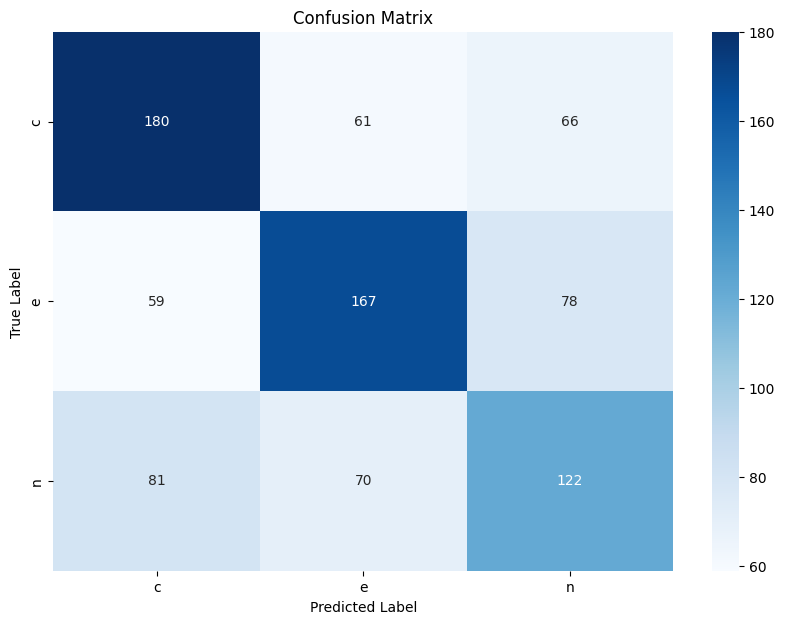

Classification Report:
              precision    recall  f1-score   support

           c       0.56      0.59      0.57       307
           e       0.56      0.55      0.55       304
           n       0.46      0.45      0.45       273

    accuracy                           0.53       884
   macro avg       0.53      0.53      0.53       884
weighted avg       0.53      0.53      0.53       884



In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'MLP Model result for {model_name} on HEB-SNLI')
res = evaluate_model(model=classifier_model, test_x=test_embeddings, y_test=snli_y_test, labels_mapping=labels_mapping)

# load HEB SNLI-FT model

In [ ]:
snli_ft_path = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/finetuning/snli'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(snli_ft_path)
model = AutoModel.from_pretrained(snli_ft_path, num_labels=3)

## preprocess lchaim dataset

In [ ]:
test_df = pd.DataFrame(test_data)
test_df['paires'] = test_df['premise'] + ' [SEP] ' + test_df['hypothesis'] + ' [SEP] '
test_pairs = test_df['paires'].tolist()
tokenized_test = tokenize_one_sample(tokenizer=tokenizer, sample=test_pairs, max_length=512)

In [ ]:
lchaim_test_data = Dataset.from_dict({
    'input_ids': tokenized_test['input_ids'],
    'attention_mask': tokenized_test['attention_mask'],
    'labels': y_test
})

In [ ]:
snli_trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

## run results on test

In [ ]:
results = snli_trainer.predict(test_dataset=lchaim_test_data)
predictions = results.predictions
label_ids = results.label_ids
metrics = results.metrics

Epoch,Training Loss,Validation Loss


(3,)

AWS LCHAIM test set after FT on SNLI


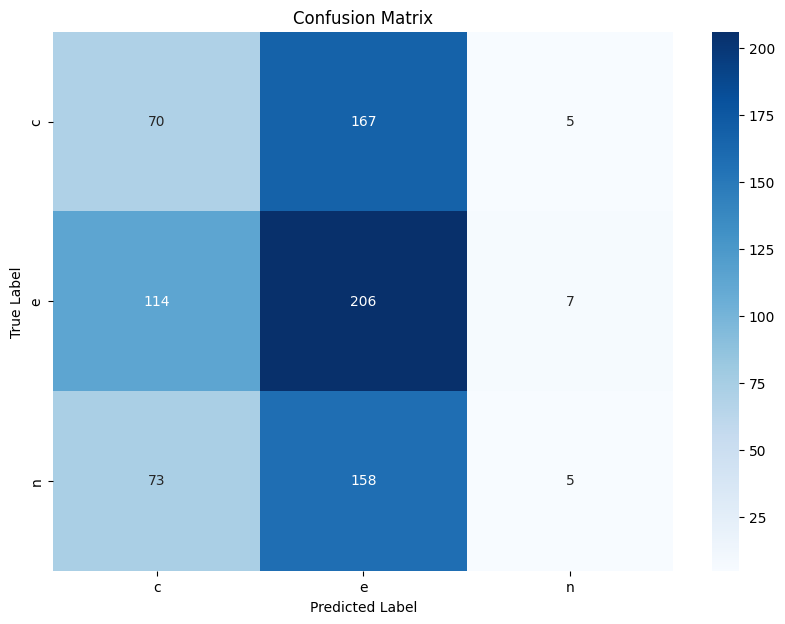

Classification Report:
              precision    recall  f1-score   support

           c       0.27      0.29      0.28       242
           e       0.39      0.63      0.48       327
           n       0.29      0.02      0.04       236

    accuracy                           0.35       805
   macro avg       0.32      0.31      0.27       805
weighted avg       0.33      0.35      0.29       805



In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print('AWS LCHAIM test set after FT on SNLI')
res = evaluate_model_base_on_preds_and_res(y_preds=predictions.argmax(axis=1), y_test=y_test.numpy(), labels_mapping=labels_mapping)